In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# 1. Carregamento e Limpeza Inicial
url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vSYXuQSSyD_gB6wUmZQEPMasncmKncWqtDSfBWz4s28PI6g6lY7JYt-mM7lF2m7onXkgPWFyg3F6l5i/pub?gid=127031286&single=true&output=csv'
df = pd.read_csv(url)

In [11]:
# Correção crítica: Converter colunas que deveriam ser numéricas mas vieram como 'object'
cols_to_fix = ['Trip_Distance_km', 'Trip_Price']
for col in cols_to_fix:
    # Tornar as colunas numéricas, removendo caracteres não numéricos
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

# Remover apenas linhas onde o alvo (Trip_Price) é nulo, pois não podemos treinar sem ele
df = df.dropna(subset=['Trip_Price'])

df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,362.6240
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,529.0320
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,364.6980
6,3.85,Afternoon,Weekday,4.0,High,Rain,3.51,1.66,NaN,5.05,11.2645
9,35.70,Afternoon,Weekday,2.0,Low,Rain,3.39,1.52,0.47,NaN,755.6570
...,...,...,...,...,...,...,...,...,...,...,...
993,NaN,Morning,Weekday,3.0,Medium,Clear,2.65,1.35,NaN,25.61,553.3480
994,18.69,Evening,Weekday,3.0,Medium,Clear,4.90,1.79,0.17,79.41,518.5480
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,344.0490
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,331.2360


In [12]:
# 2. Definição das Features
target = 'Trip_Price'
num_features = ['Trip_Distance_km', 'Passenger_Count', 'Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration_Minutes']
cat_features = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']

X = df[num_features + cat_features]
y = df[target].values.reshape(-1, 1)

In [13]:
# 3. Pipeline de Pré-processamento
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ])

# Aplicar transformações
X_transformed = preprocessor.fit_transform(X)
if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

In [14]:
# 4. Preparação para o PyTorch
class TaxiDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = TaxiDataset(X_transformed, y)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [15]:
# 5. Modelo de Regressão Linear
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)
        
    def forward(self, x):
        return self.linear(x)

input_dim = X_transformed.shape[1]
model = LinearRegressionModel(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [16]:
# 6. Treinamento
epochs = 3000
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}')

print("Treinamento concluído.")

Epoch [10/3000], Loss: 230546.1385
Epoch [20/3000], Loss: 226749.0365
Epoch [30/3000], Loss: 219745.3479
Epoch [40/3000], Loss: 212834.1458
Epoch [50/3000], Loss: 208039.2167
Epoch [60/3000], Loss: 203650.7896
Epoch [70/3000], Loss: 198467.9219
Epoch [80/3000], Loss: 192580.6385
Epoch [90/3000], Loss: 186720.7135
Epoch [100/3000], Loss: 181296.8125
Epoch [110/3000], Loss: 175979.5583
Epoch [120/3000], Loss: 172696.8292
Epoch [130/3000], Loss: 168979.6250
Epoch [140/3000], Loss: 163333.9578
Epoch [150/3000], Loss: 158756.5828
Epoch [160/3000], Loss: 154646.7458
Epoch [170/3000], Loss: 150678.1406
Epoch [180/3000], Loss: 145021.4521
Epoch [190/3000], Loss: 141044.9969
Epoch [200/3000], Loss: 137233.7781
Epoch [210/3000], Loss: 132407.3552
Epoch [220/3000], Loss: 129653.1443
Epoch [230/3000], Loss: 125110.1552
Epoch [240/3000], Loss: 122806.4078
Epoch [250/3000], Loss: 118583.2406
Epoch [260/3000], Loss: 115787.3917
Epoch [270/3000], Loss: 113198.3406
Epoch [280/3000], Loss: 109735.7490
E

In [17]:
from sklearn.metrics import r2_score
# 7. Avaliação do Modelo nos Dados de Teste
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        y_true.extend(batch_y.numpy())
        y_pred.extend(outputs.numpy())

# Converter para arrays numpy para facilitar a plotagem
y_true = np.array(y_true).flatten()
y_pred = np.array(y_pred).flatten()

r2 = r2_score(y_true, y_pred)
print(f'\nCoeficiente de Determinação (R²): {r2:.4f}')



Coeficiente de Determinação (R²): 0.4485


Gráfico gerado com sucesso!


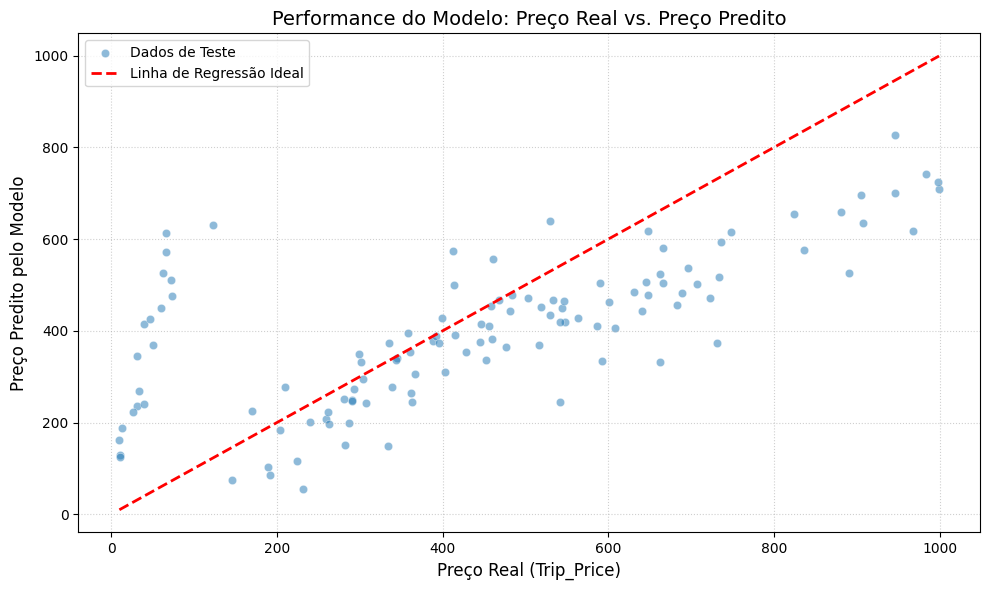

In [18]:
# 8. Visualização dos Resultados
plt.figure(figsize=(10, 6))

# Plotar os pontos (Valores Reais vs Preditos)
sns.scatterplot(x=y_true, y=y_pred, alpha=0.5, label='Dados de Teste')

# Plotar a linha de referência (Identidade) - Onde os pontos deveriam estar
line_coords = np.linspace(min(y_true), max(y_true), 100)
plt.plot(line_coords, line_coords, color='red', linestyle='--', linewidth=2, label='Linha de Regressão Ideal')

plt.title('Performance do Modelo: Preço Real vs. Preço Predito', fontsize=14)
plt.xlabel('Preço Real (Trip_Price)', fontsize=12)
plt.ylabel('Preço Predito pelo Modelo', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Salvar e exibir
plt.tight_layout()
plt.savefig('resultado_regressao.png')
# plt.show() # Descomente se estiver no Jupyter/Colab

print("Gráfico gerado com sucesso!")